# Iterative Weight Suppression Analysis for RKM Models

This notebook focuses on the **iterative suppression with fine-tuning** method, providing detailed analysis of how model performance changes as hidden nodes are progressively removed.

## Method Overview

The iterative suppression method:
1. **Identifies** the least-used hidden node (lowest total connection strength)
2. **Suppresses** the entire node (sets all connections to zero)
3. **Fine-tunes** remaining weights to adapt to the new structure
4. **Evaluates** performance and continues until target sparsity or performance threshold
5. **Self-regulates** by stopping if performance degrades too much


## Setup and Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
import sys
import warnings

warnings.filterwarnings('ignore')

# Import pyrkm and our simplified weight suppression toolkit v2
import pyrkm

# Set up plotting for detailed analysis
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

## Configuration and Data Setup

In [2]:
# Configuration
GLOBAL_DTYPE = torch.float32
torch.set_default_dtype(GLOBAL_DTYPE)

# Device setup
gpu_id = 0
os.environ['CUDA_VISIBLE_DEVICES'] = str(gpu_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device == 'cpu':
    torch.set_num_threads(24)

print(f"Using device: {device}")
print(f"Global dtype: {GLOBAL_DTYPE}")

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
Global dtype: torch.float32


In [3]:
# Create directories
pyrkm.ensure_dir('model_states')
pyrkm.ensure_dir('iterative_results')

# Load MNIST data
print("Loading MNIST data...")
qmnist = pyrkm.unpickle("../datasets/MNIST-120k")
data = qmnist['data']
labels = qmnist['labels']

# Prepare data
if len(data.shape) > 2:
    train_data = np.reshape(data, newshape=(data.shape[0], 784)) / 255
else:
    train_data = data / 255

# Split data
test_size = 500
train_size = 10000

testing_data = train_data[:test_size, :]
train_data = train_data[test_size:test_size + train_size]

# Convert to tensors and binarize
testing_data = torch.Tensor(testing_data).to(GLOBAL_DTYPE)
train_data = torch.Tensor(train_data).to(GLOBAL_DTYPE)

train_data = torch.where(train_data > 0.5, 1.0, 0.0)
testing_data = torch.where(testing_data > 0.5, 1.0, 0.0)

print(f"Training data: {train_data.shape}, Testing data: {testing_data.shape}")

Loading MNIST data...
Training data: torch.Size([10000, 784]), Testing data: torch.Size([500, 784])


## Model Loading or Training

In [4]:
# Model parameters
nhidden = 500
max_epochs = 50000
batch_size = 64
lr = 0.001
optimizer = 'SGD'
energy_type = 'hopfield'
regul_to_use = 'l1_hidden_nodes'
#regul_to_use = 'l1'
l1factor = 1e-4
k = 1
train_algo = 'PCD'
model_beta = 1

# Generate model name
model_name = f'nh{nhidden}_{energy_type}{max_epochs}_beta{model_beta}_l1hn{l1factor}_{train_algo}{k}_{optimizer}_lr{lr}_bs{batch_size}_iterative_analysis'

print(f'Model name: {model_name}')

Model name: nh500_hopfield50000_beta1_l1hn0.0001_PCD1_SGD_lr0.001_bs64_iterative_analysis


In [5]:
# Load or create model
is_loadable, model = pyrkm.load_model(model_name, delete_previous=False)

if not is_loadable:
    print("Creating and training new model...")

    average_data = torch.Tensor(train_data).mean(0).to(GLOBAL_DTYPE)
    train_loader = torch.utils.data.DataLoader(train_data.to(device),
                                               batch_size=batch_size,
                                               shuffle=True,
                                               drop_last=True)

    model = pyrkm.RKM(model_name=model_name,
                      n_visible=784,
                      n_hidden=nhidden,
                      k=k,
                      lr=lr,
                      max_epochs=max_epochs,
                      energy_type=energy_type,
                      optimizer=optimizer,
                      batch_size=batch_size,
                      train_algo=train_algo,
                      centering=False,
                      average_data=average_data,
                      model_beta=model_beta,
                      mytype=GLOBAL_DTYPE,
                      regularization=regul_to_use,
                      l1_factor=l1factor)

    model.train(train_loader, testing_data.to(model.device), print_error=True)
    print("Training completed!")
else:
    print(f"Loaded existing model: {model_name}")

print(f"Model: {model.n_visible} visible, {model.n_hidden} hidden units")
print(f"Total weights: {model.W.numel()}")
print(f"Regularization: {getattr(model, 'regularization', 'None')}")

** No load points for nh500_hopfield50000_beta1_l1hn0.0001_PCD1_SGD_lr0.001_bs64_iterative_analysis
Creating and training new model...
*** Initializing nh500_hopfield50000_beta1_l1hn0.0001_PCD1_SGD_lr0.001_bs64_iterative_analysis
The model is working on the following device: cuda
Epoch: 100 , train-err 0.23738 , time: 0.008688
Epoch: 200 , train-err 0.20159 , time: 0.012675
Epoch: 300 , train-err 0.18469 , time: 0.008815
Epoch: 400 , train-err 0.18993 , time: 0.008320
Epoch: 500 , train-err 0.18152 , time: 0.008217
Epoch: 600 , train-err 0.18166 , time: 0.008581
Epoch: 700 , train-err 0.18395 , time: 0.008486
Epoch: 800 , train-err 0.17789 , time: 0.008600
Epoch: 900 , train-err 0.18537 , time: 0.008403
Epoch: 1000 , train-err 0.1816 , time: 0.008632
Epoch: 1100 , train-err 0.18587 , time: 0.008747
Epoch: 1200 , train-err 0.18276 , time: 0.008270
Epoch: 1300 , train-err 0.18431 , time: 0.008105
Epoch: 1400 , train-err 0.18196 , time: 0.008180
Epoch: 1500 , train-err 0.17759 , time: 0.0

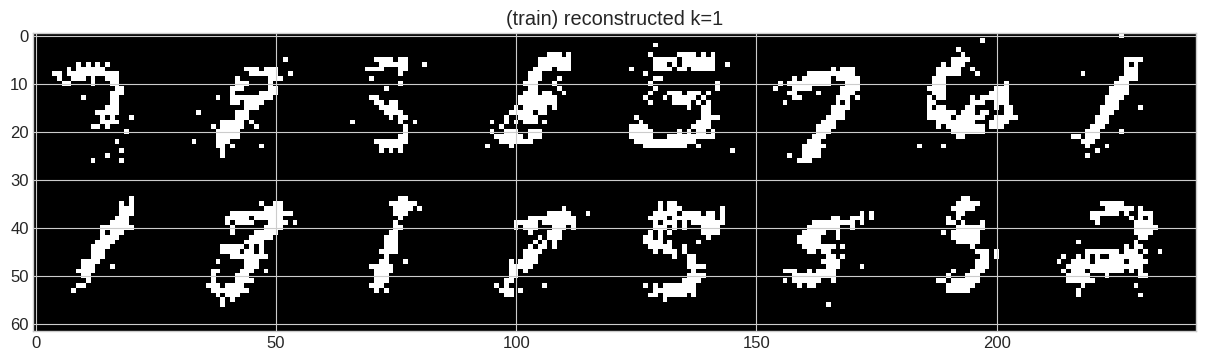

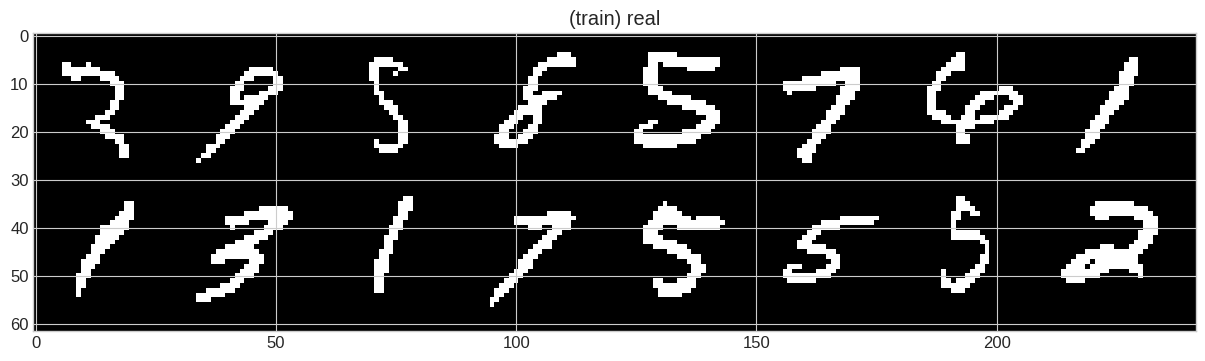

In [19]:
# Check reconstruction performance
testing_data = train_data[:16]
k_gibbs_list = [1]
for tg_multiple in k_gibbs_list:
    v_original, v_reconstructed = model.reconstruct(testing_data,
                                                    tg_multiple * k)
    pyrkm.show_and_save("(train) reconstructed k={}".format(tg_multiple * k),
                        pyrkm.make_grid(
                            np.reshape(v_reconstructed,
                                       newshape=(-1, 28, 28))),
                        save=False)
    plt.show()
pyrkm.show_and_save(
    "(train) real",
    pyrkm.make_grid(np.reshape(v_original, newshape=(-1, 28, 28))))
plt.show()

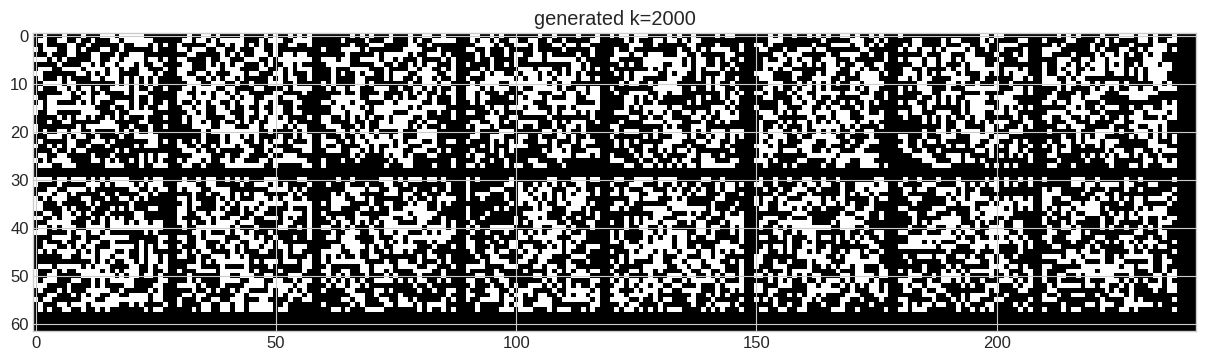

In [20]:
# Check Generative performance
gsteps_list = [2000]
for tg_multiple in gsteps_list:
    v_generated = model.generate(16, tg_multiple * k, from_visible=True)
    pyrkm.show_and_save(
        "generated k={}".format(tg_multiple * k),
        pyrkm.make_grid(np.reshape(v_generated, newshape=(-1, 28, 28))))
    plt.show()

## Iterative Suppression Analysis

Now we'll run the iterative suppression method with detailed tracking of each iteration.

In [ ]:
# Create analyzer
testing_data_consistent = testing_data.to(model.device).to(model.mytype)
analyzer = pyrkm.WeightSuppressionAnalyzer(model, testing_data_consistent)

print("🎯 ITERATIVE SUPPRESSION WITH FINE-TUNING")
print("=" * 50)
print(
    f"Original model: {model.n_hidden} hidden nodes, {model.W.numel()} weights"
)
print(
    f"Baseline reconstruction error: {analyzer.baseline_metrics['reconstruction_error']:.4f}"
)
print("=" * 50)

🎯 ITERATIVE SUPPRESSION WITH FINE-TUNING
Original model: 500 hidden nodes, 392000 weights
Baseline reconstruction error: 0.0676


In [7]:
model.verbose = False  # Disable verbose output during fine-tuning

# Run iterative node removal - target 80% of hidden nodes removed
target_node_removal_ratio = 0.7  # Remove 80% of hidden nodes
target_nodes_to_remove = int(model.n_hidden * target_node_removal_ratio)
all_iterative_results = {}

print("🔄 ITERATIVE NODE REMOVAL")
print("=" * 60)
print(
    f"Removing {target_node_removal_ratio:.0%} of hidden nodes ({target_nodes_to_remove} out of {model.n_hidden})"
)
print("Tracking intermediate model weights and reconstruction accuracy...")
print("=" * 60)

# Run iterative suppression until we remove 80% of nodes
# Convert to equivalent sparsity (rough estimate for stopping condition)
# Each node removal affects: n_visible weights + 1 hidden bias + some visible bias impact
weights_per_node = model.n_visible + 1  # Approximate
total_weights = model.W.numel() + model.h_bias.numel() + model.v_bias.numel()
estimated_target_sparsity = min(
    0.95, (target_nodes_to_remove * weights_per_node) / total_weights)

iterative_results = analyzer.iterative_suppression_with_fine_tuning(
    target_sparsity=estimated_target_sparsity,
    fine_tune_epochs=1000,  # Faster execution with fewer epochs
    lr_factor=1,
    train_data=train_data,
    verbose=False  # Disable verbose output
)

if iterative_results:
    print(
        f"\n✅ Node removal completed with {len(iterative_results)} iterations")

    # Store all intermediate results (each iteration = one node removed)
    all_iterative_results['node_removal_progression'] = iterative_results

    # Show progress at key milestones
    milestones = [0.05, 0.1, 0.15, 0.2, 0.4, 0.6,
                  0.8]  # 5%, 10%, 15%, 20%, 40%, 60%, 80%

    for milestone in milestones:
        target_iteration = int(model.n_hidden * milestone)

        # Find closest iteration to this milestone
        closest_iter = None
        min_diff = float('inf')
        for config_name, metrics in iterative_results.items():
            diff = abs(metrics['iteration'] - target_iteration)
            if diff < min_diff:
                min_diff = diff
                closest_iter = (config_name, metrics)

        if closest_iter:
            config_name, metrics = closest_iter
            nodes_removed_ratio = metrics['iteration'] / model.n_hidden
            nodes_remaining = model.n_hidden - metrics['iteration']
            suppressed_node = metrics['suppressed_node']
            print(
                f"📊 {milestone:.0%} milestone: Iteration {metrics['iteration']} "
                f"({nodes_removed_ratio:.1%} nodes removed) - "
                f"Removed node {suppressed_node}, {nodes_remaining} nodes left, "
                f"reconstruction error ratio: {metrics['reconstruction_error_ratio']:.3f}"
            )

    # Show detailed step-by-step progression for first 10 and last 10 iterations
    print(f"\n🔍 DETAILED NODE REMOVAL PROGRESSION:")
    print("-" * 80)
    print(
        f"{'Step':<5} {'Node Removed':<12} {'Nodes Left':<11} {'Reconstruction Ratio':<18} {'Node Strength'}"
    )
    print("-" * 80)

    # Sort by iteration
    sorted_iterations = sorted(iterative_results.items(),
                               key=lambda x: x[1]['iteration'])

    # Show first 10 iterations
    for i, (config_name, metrics) in enumerate(sorted_iterations[:10]):
        step = metrics['iteration']
        node_removed = metrics['suppressed_node']
        nodes_left = model.n_hidden - step
        recon_ratio = metrics['reconstruction_error_ratio']
        node_strength = metrics['node_strength']
        print(
            f"{step:<5} {node_removed:<12} {nodes_left:<11} {recon_ratio:<18.3f} {node_strength:.3f}"
        )

    # Show ellipsis if more than 20 iterations
    if len(sorted_iterations) > 20:
        print("  ... (intermediate steps omitted) ...")

    # Show last 10 iterations (if more than 10 total)
    if len(sorted_iterations) > 10:
        start_idx = max(10, len(sorted_iterations) - 10)
        for i, (config_name,
                metrics) in enumerate(sorted_iterations[start_idx:]):
            step = metrics['iteration']
            node_removed = metrics['suppressed_node']
            nodes_left = model.n_hidden - step
            recon_ratio = metrics['reconstruction_error_ratio']
            node_strength = metrics['node_strength']
            print(
                f"{step:<5} {node_removed:<12} {nodes_left:<11} {recon_ratio:<18.3f} {node_strength:.3f}"
            )

    print("-" * 80)

else:
    print("❌ No results generated from iterative node removal")

print(f"\n{'='*60}")
print(f"Node removal analysis complete!")

# Show summary of what was achieved
if 'node_removal_progression' in all_iterative_results:
    progression_results = all_iterative_results['node_removal_progression']
    final_config = max(progression_results.keys(),
                       key=lambda x: progression_results[x]['iteration'])
    final_metrics = progression_results[final_config]

    nodes_removed = final_metrics['iteration']
    nodes_removed_ratio = nodes_removed / model.n_hidden
    remaining_nodes = model.n_hidden - nodes_removed

    print(f"\n🏆 FINAL NODE REMOVAL RESULTS:")
    print(
        f"   Nodes removed: {nodes_removed} out of {model.n_hidden} ({nodes_removed_ratio:.1%})"
    )
    print(f"   Remaining active nodes: {remaining_nodes}")
    print(
        f"   Final reconstruction error ratio: {final_metrics['reconstruction_error_ratio']:.3f}"
    )
    print(f"   Total iterations completed: {final_metrics['iteration']}")

    print(
        f"\n📊 All intermediate results stored with model weights and reconstruction accuracy."
    )

🔄 ITERATIVE NODE REMOVAL
Removing 70% of hidden nodes (350 out of 500)
Tracking intermediate model weights and reconstruction accuracy...

✅ Node removal completed with 349 iterations
📊 5% milestone: Iteration 25 (5.0% nodes removed) - Removed node 187, 475 nodes left, reconstruction error ratio: 1.029
📊 10% milestone: Iteration 50 (10.0% nodes removed) - Removed node 162, 450 nodes left, reconstruction error ratio: 1.082
📊 15% milestone: Iteration 75 (15.0% nodes removed) - Removed node 137, 425 nodes left, reconstruction error ratio: 1.135
📊 20% milestone: Iteration 100 (20.0% nodes removed) - Removed node 112, 400 nodes left, reconstruction error ratio: 1.194
📊 40% milestone: Iteration 200 (40.0% nodes removed) - Removed node 81, 300 nodes left, reconstruction error ratio: 1.268
📊 60% milestone: Iteration 300 (60.0% nodes removed) - Removed node 81, 200 nodes left, reconstruction error ratio: 1.267
📊 80% milestone: Iteration 349 (69.8% nodes removed) - Removed node 81, 151 nodes lef

## Detailed Performance Tracking

Let's analyze how performance changes with each node removal iteration.

Creating reconstruction error vs node removal visualization...


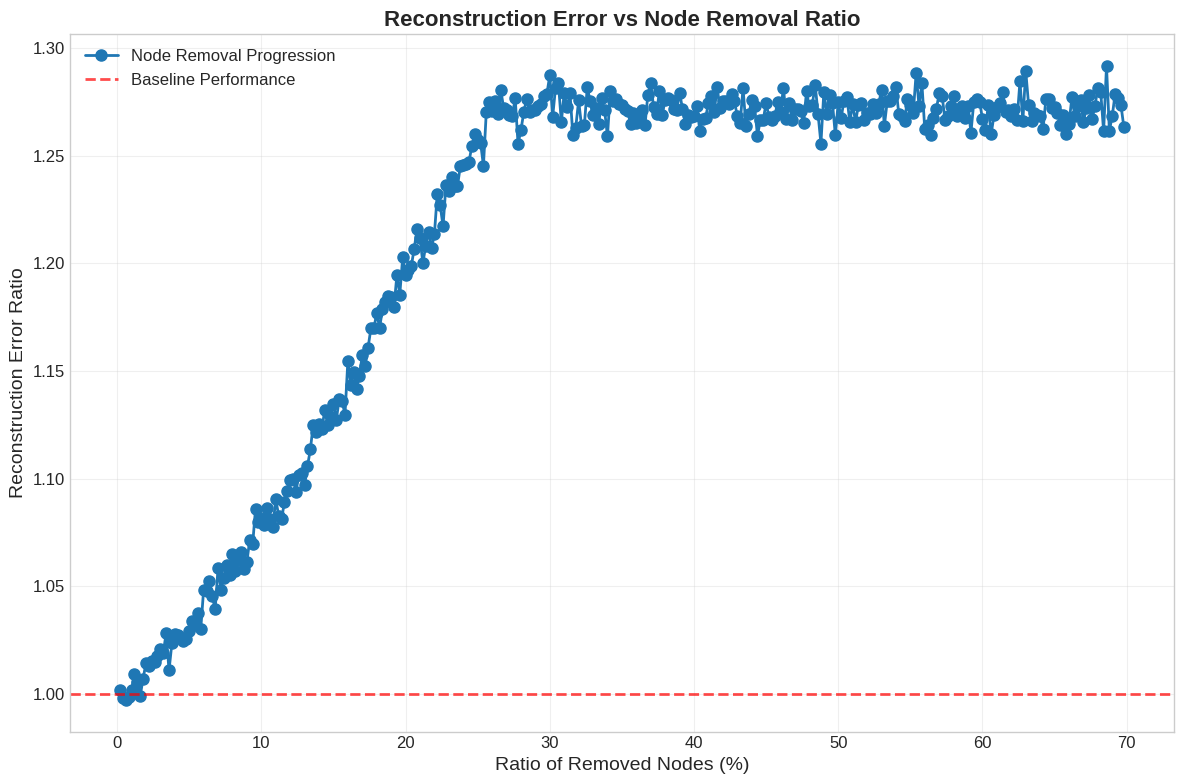

✅ Simplified visualization saved: iterative_results/reconstruction_error_vs_node_removal.png


In [8]:
# Simple visualization: Reconstruction Error vs Ratio of Removed Nodes
if all_iterative_results:
    print("Creating reconstruction error vs node removal visualization...")

    plt.figure(figsize=(12, 8))

    # Define colors for different target sparsities
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    # Use complete_sweep data if that's all we have, otherwise use target-specific data
    if 'complete_sweep' in all_iterative_results and len(
            all_iterative_results) == 1:
        # Only complete_sweep exists, use that
        results = all_iterative_results['complete_sweep']
        if results:
            # Calculate ratio of removed nodes (iterations / total hidden nodes)
            node_removal_ratios = [
                metrics['iteration'] / model.n_hidden * 100
                for metrics in results.values()
            ]
            recon_ratios = [
                metrics['reconstruction_error_ratio']
                for metrics in results.values()
            ]

            # Plot the complete progression
            plt.plot(node_removal_ratios,
                     recon_ratios,
                     'o-',
                     color=colors[0],
                     label='Complete Iterative Suppression',
                     linewidth=2,
                     markersize=6)
    else:
        # Use target-specific data
        for i, (target_name,
                results) in enumerate(all_iterative_results.items()):
            if results and target_name != 'complete_sweep':
                # Calculate ratio of removed nodes (iterations / total hidden nodes)
                node_removal_ratios = [
                    metrics['iteration'] / model.n_hidden * 100
                    for metrics in results.values()
                ]
                recon_ratios = [
                    metrics['reconstruction_error_ratio']
                    for metrics in results.values()
                ]

                # Plot the progression
                plt.plot(
                    node_removal_ratios,
                    recon_ratios,
                    'o-',
                    color=colors[i % len(colors)],
                    label=
                    f'{target_name.replace("target_", "").replace("_", " ").title()}',
                    linewidth=2,
                    markersize=8)

    # Add baseline reference
    plt.axhline(y=1.0,
                color='red',
                linestyle='--',
                alpha=0.7,
                linewidth=2,
                label='Baseline Performance')

    plt.xlabel('Ratio of Removed Nodes (%)', fontsize=14)
    plt.ylabel('Reconstruction Error Ratio', fontsize=14)
    plt.title('Reconstruction Error vs Node Removal Ratio',
              fontsize=16,
              fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Improve layout
    plt.tight_layout()
    plt.savefig('iterative_results/reconstruction_error_vs_node_removal.png',
                dpi=300,
                bbox_inches='tight')
    plt.show()

    print(
        "✅ Simplified visualization saved: iterative_results/reconstruction_error_vs_node_removal.png"
    )
else:
    print("❌ No results available for visualization")

## Model Quality Visualization

Let's visualize how the iterative suppression affects the model's ability to reconstruct MNIST digits.

Creating model quality visualization 


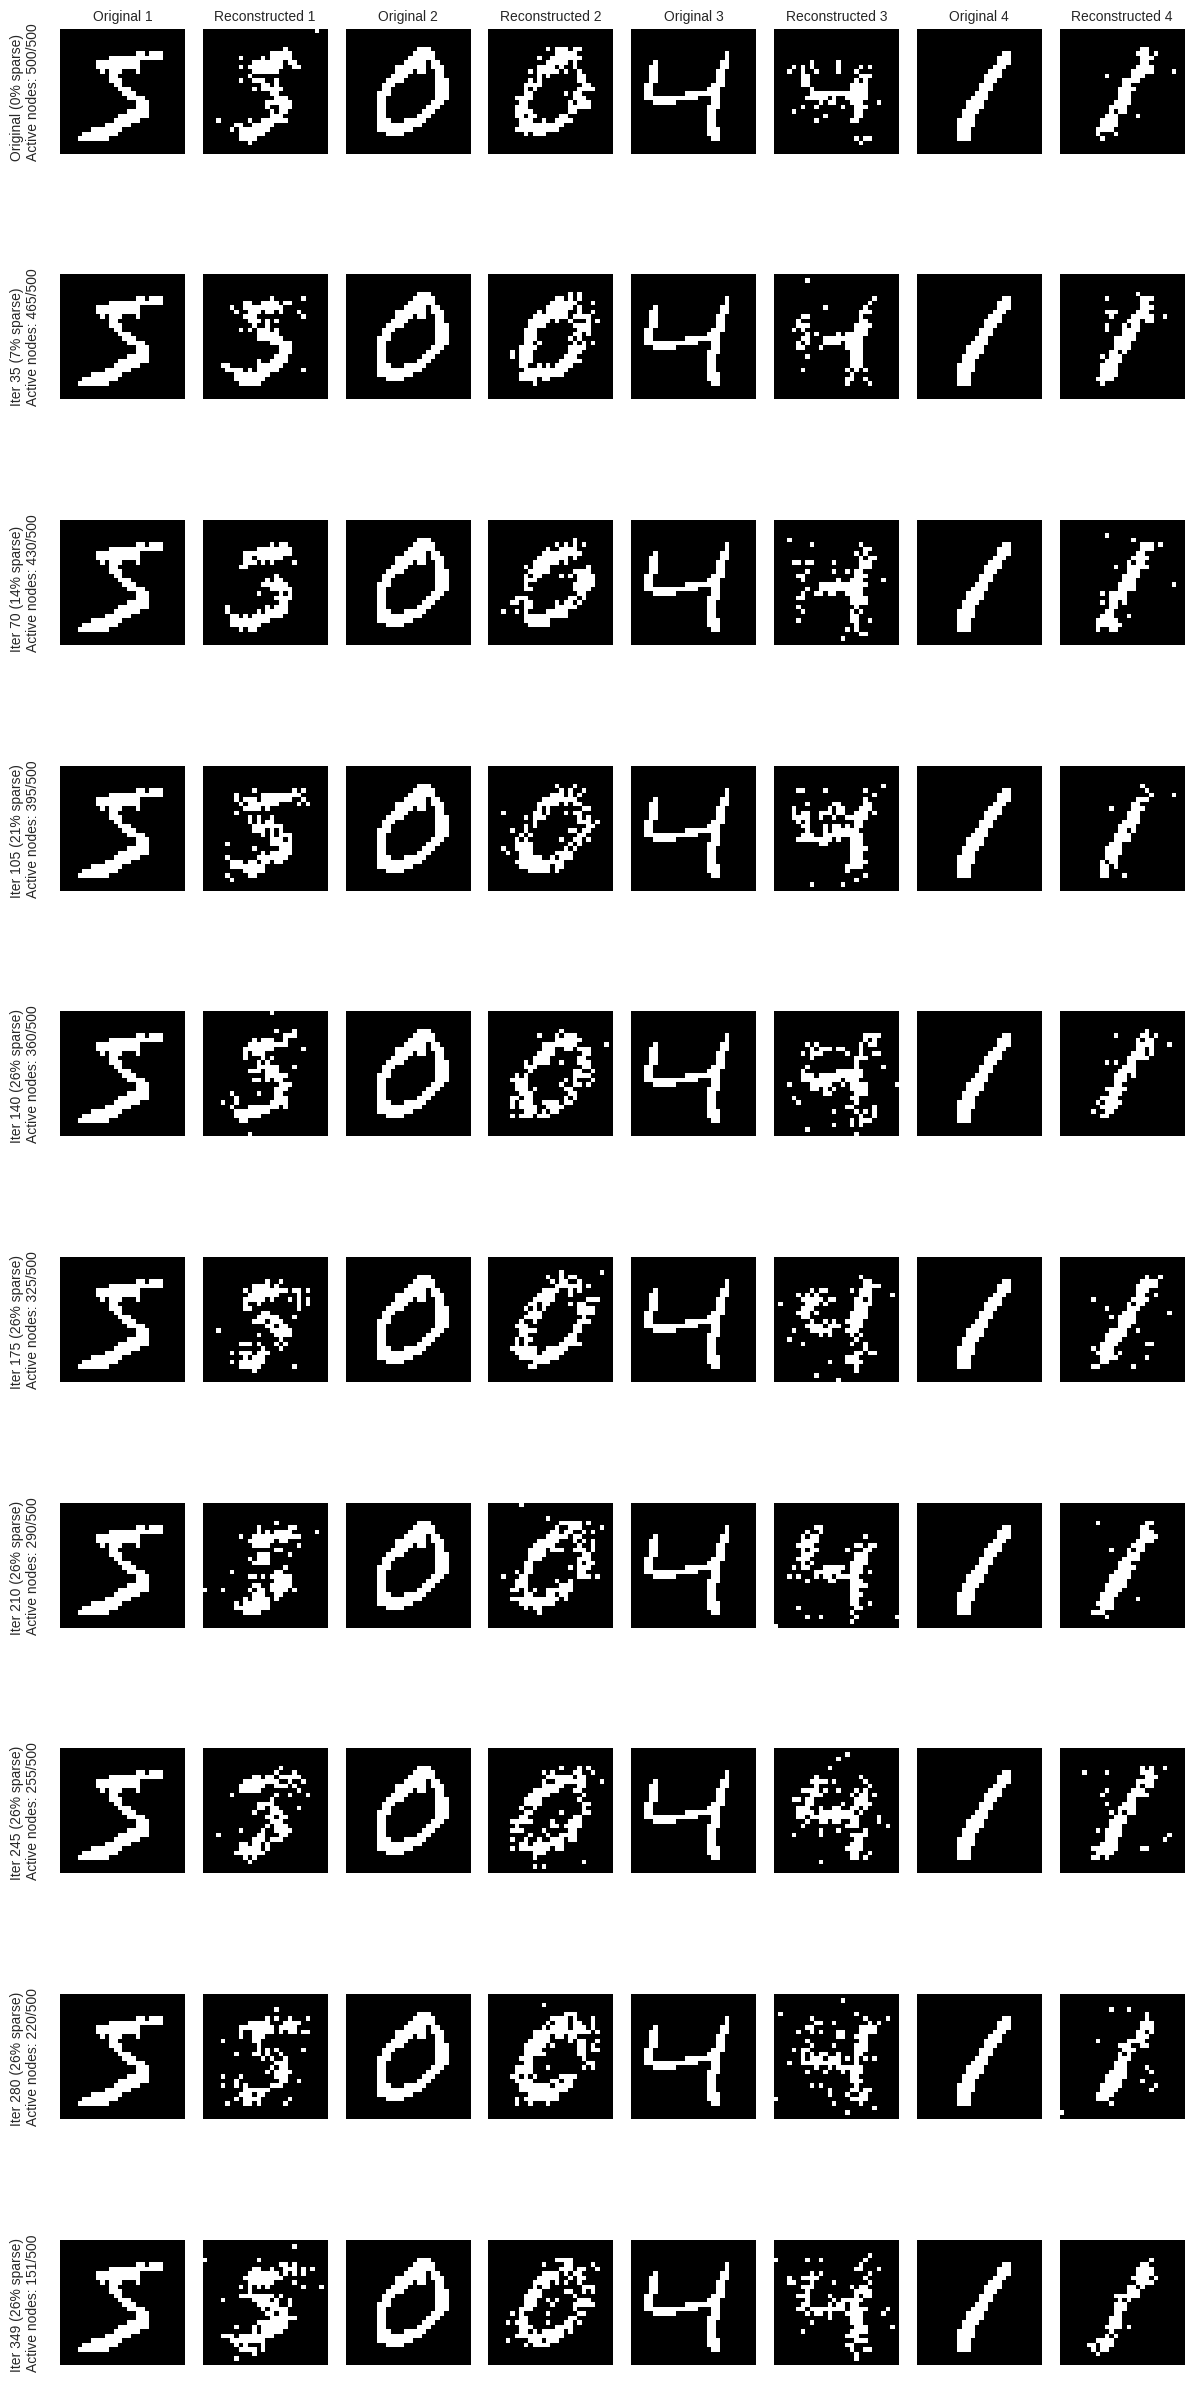

✅ Detailed model quality comparison saved: iterative_results/model_quality_comparison_detailed.png

🎯 SPARSITY LEVELS VISUALIZED:
--------------------------------------------------
   1. Iteration   0: 500 active nodes
   2. Iteration  35: 465 active nodes
   3. Iteration  70: 430 active nodes
   4. Iteration 105: 395 active nodes
   5. Iteration 140: 360 active nodes
   6. Iteration 175: 325 active nodes
   7. Iteration 210: 290 active nodes
   8. Iteration 245: 255 active nodes
   9. Iteration 280: 220 active nodes
  10. Iteration 349: 151 active nodes


In [ ]:
# Visual comparison of model reconstruction quality - 4 digits, more sparsity levels
if all_iterative_results:
    print("Creating model quality visualization ")

    # Select models at different sparsity levels for detailed comparison
    models_to_compare = []

    # Original model
    models_to_compare.append({
        'name': 'Original (0% sparse)',
        'model': model,
        'sparsity': 0.0
    })

    # Select models at regular intervals across the full progression
    for target_name, results in all_iterative_results.items():
        if results:
            sorted_configs = sorted(results.items(),
                                    key=lambda x: x[1]['iteration'])

            # Take models at regular intervals: 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%+ of progression
            total_iterations = len(sorted_configs)
            sparsity_intervals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                  1.0]  # Final one at end

            for interval in sparsity_intervals:
                idx = min(int(interval * total_iterations),
                          total_iterations - 1)
                if idx < len(sorted_configs):
                    config_name, metrics = sorted_configs[idx]

                    # Calculate sparsity from the model since it's not stored in metrics
                    current_model = metrics['model']
                    W_zeros = (current_model.W == 0).sum().item()
                    h_bias_zeros = (current_model.h_bias == 0).sum().item()
                    v_bias_zeros = (current_model.v_bias == 0).sum().item()
                    current_suppressed = W_zeros + h_bias_zeros + v_bias_zeros
                    total_weights = metrics['total_weights']
                    current_sparsity = current_suppressed / total_weights

                    models_to_compare.append({
                        'name':
                        f'Iter {metrics["iteration"]} ({current_sparsity:.0%} sparse)',
                        'model': metrics['model'],
                        'sparsity': current_sparsity,
                        'iteration': metrics['iteration']
                    })

    # Remove duplicates based on iteration and limit to reasonable number
    seen_iterations = set()
    unique_models = []
    for model_info in models_to_compare:
        iteration = model_info.get('iteration', 0)
        if iteration not in seen_iterations:
            unique_models.append(model_info)
            seen_iterations.add(iteration)

    models_to_compare = unique_models[:10]  # Limit to 10 models max

    # Create visualization with only 4 digits
    n_samples = 4  # Reduced from 8 to 4
    test_samples = testing_data[:n_samples]

    fig, axes = plt.subplots(len(models_to_compare),
                             n_samples * 2,
                             figsize=(12, 2.5 * len(models_to_compare)))
    if len(models_to_compare) == 1:
        axes = axes.reshape(1, -1)

    for i, model_info in enumerate(models_to_compare):
        current_model = model_info['model']
        model_name = model_info['name']

        # Generate reconstructions
        with torch.no_grad():
            reconstructions = current_model.forward(
                test_samples.to(current_model.device), current_model.k)
            reconstructions = reconstructions.cpu()

        # Plot original and reconstructed images (4 pairs)
        for j in range(n_samples):
            # Original image
            axes[i, j * 2].imshow(test_samples[j].reshape(28, 28), cmap='gray')
            axes[i, j * 2].axis('off')
            if i == 0:
                axes[i, j * 2].set_title(f'Original {j+1}', fontsize=10)

            # Reconstructed image
            axes[i, j * 2 + 1].imshow(reconstructions[j].reshape(28, 28),
                                      cmap='gray')
            axes[i, j * 2 + 1].axis('off')
            if i == 0:
                axes[i, j * 2 + 1].set_title(f'Reconstructed {j+1}',
                                             fontsize=10)

        # Add model info on the left with more details
        iteration = model_info.get('iteration', 0)
        remaining_nodes = model.n_hidden - iteration
        info_text = f'{model_name}\nActive nodes: {remaining_nodes}/{model.n_hidden}'

        axes[i, 0].text(-0.4,
                        0.5,
                        info_text,
                        transform=axes[i, 0].transAxes,
                        fontsize=10,
                        verticalalignment='center',
                        rotation=90)

    plt.tight_layout()
    plt.savefig('iterative_results/model_quality_comparison_detailed.png',
                dpi=300,
                bbox_inches='tight')
    plt.show()

    print(
        "✅ Detailed model quality comparison saved: iterative_results/model_quality_comparison_detailed.png"
    )

    # Print summary of models shown
    print(f"\n🎯 SPARSITY LEVELS VISUALIZED:")
    print("-" * 50)
    for i, model_info in enumerate(models_to_compare):
        iteration = model_info.get('iteration', 0)
        remaining_nodes = model.n_hidden - iteration
        print(
            f"  {i+1:2d}. Iteration {iteration:3d}: {remaining_nodes:3d} active nodes"
        )

else:
    print("❌ No models available for quality comparison")

Creating model generation quality visualization with more sparsity levels...


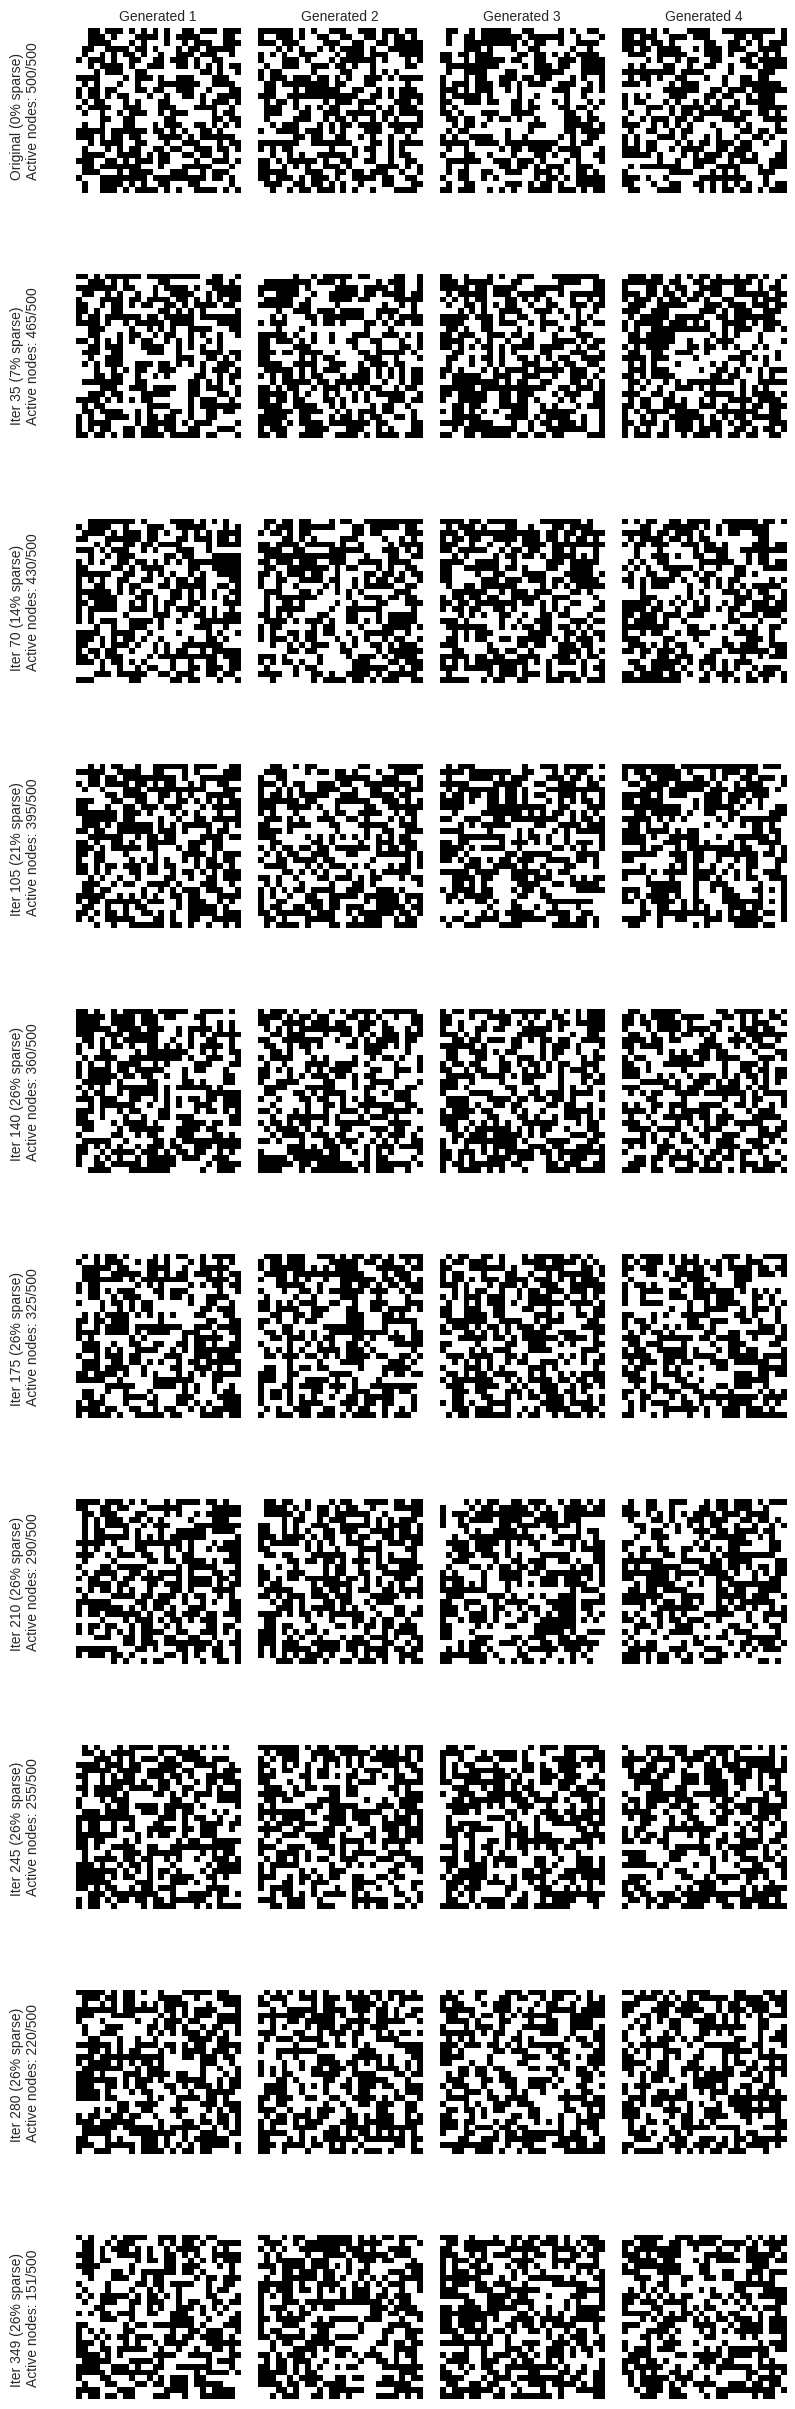

✅ Detailed model generation comparison saved: iterative_results/model_generation_comparison_detailed.png
📊 Showing 10 sparsity levels with 4 generated digits each

🎯 GENERATION QUALITY AT DIFFERENT SPARSITY LEVELS:
--------------------------------------------------
   1. Iteration   0:  0.0% sparse, 500 active nodes
   2. Iteration  35:  7.0% sparse, 465 active nodes
   3. Iteration  70: 14.0% sparse, 430 active nodes
   4. Iteration 105: 21.0% sparse, 395 active nodes
   5. Iteration 140: 25.9% sparse, 360 active nodes
   6. Iteration 175: 25.9% sparse, 325 active nodes
   7. Iteration 210: 25.9% sparse, 290 active nodes
   8. Iteration 245: 25.9% sparse, 255 active nodes
   9. Iteration 280: 25.9% sparse, 220 active nodes
  10. Iteration 349: 25.9% sparse, 151 active nodes


In [16]:
# Visual comparison of model generation quality - 4 generated digits, more sparsity levels
if all_iterative_results:
    print(
        "Creating model generation quality visualization with more sparsity levels..."
    )

    # Select models at different sparsity levels for detailed comparison
    models_to_compare = []

    # Original model
    models_to_compare.append({
        'name': 'Original (0% sparse)',
        'model': model,
        'sparsity': 0.0
    })

    # Select models at regular intervals across the full progression
    for target_name, results in all_iterative_results.items():
        if results:
            sorted_configs = sorted(results.items(),
                                    key=lambda x: x[1]['iteration'])

            # Take models at regular intervals: 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%+ of progression
            total_iterations = len(sorted_configs)
            sparsity_intervals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8,
                                  1.0]  # Final one at end

            for interval in sparsity_intervals:
                idx = min(int(interval * total_iterations),
                          total_iterations - 1)
                if idx < len(sorted_configs):
                    config_name, metrics = sorted_configs[idx]

                    # Calculate sparsity from the model since it's not stored in metrics
                    current_model = metrics['model']
                    W_zeros = (current_model.W == 0).sum().item()
                    h_bias_zeros = (current_model.h_bias == 0).sum().item()
                    v_bias_zeros = (current_model.v_bias == 0).sum().item()
                    current_suppressed = W_zeros + h_bias_zeros + v_bias_zeros
                    total_weights = metrics['total_weights']
                    current_sparsity = current_suppressed / total_weights

                    models_to_compare.append({
                        'name':
                        f'Iter {metrics["iteration"]} ({current_sparsity:.0%} sparse)',
                        'model': metrics['model'],
                        'sparsity': current_sparsity,
                        'iteration': metrics['iteration']
                    })

    # Remove duplicates based on iteration and limit to reasonable number
    seen_iterations = set()
    unique_models = []
    for model_info in models_to_compare:
        iteration = model_info.get('iteration', 0)
        if iteration not in seen_iterations:
            unique_models.append(model_info)
            seen_iterations.add(iteration)

    models_to_compare = unique_models[:10]  # Limit to 10 models max

    # Create visualization with 4 generated digits
    n_samples = 4

    fig, axes = plt.subplots(len(models_to_compare),
                             n_samples,
                             figsize=(8, 2.5 * len(models_to_compare)))
    if len(models_to_compare) == 1:
        axes = axes.reshape(1, -1)

    for i, model_info in enumerate(models_to_compare):
        current_model = model_info['model']
        model_name = model_info['name']
        sparsity = model_info['sparsity']

        # Generate samples from the model using Gibbs sampling
        gibbs_steps = 10000
        with torch.no_grad():
            generated_samples = current_model.generate(n_samples,
                                                       gibbs_steps,
                                                       from_visible=True)

        # Plot generated images
        for j in range(n_samples):
            axes[i, j].imshow(generated_samples[j].reshape(28, 28),
                              cmap='gray')
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(f'Generated {j+1}', fontsize=10)

        # Add model info on the left with more details
        iteration = model_info.get('iteration', 0)
        remaining_nodes = model.n_hidden - iteration
        info_text = f'{model_name}\nActive nodes: {remaining_nodes}/{model.n_hidden}'

        axes[i, 0].text(-0.4,
                        0.5,
                        info_text,
                        transform=axes[i, 0].transAxes,
                        fontsize=10,
                        verticalalignment='center',
                        rotation=90)

    plt.tight_layout()
    plt.savefig('iterative_results/model_generation_comparison_detailed.png',
                dpi=300,
                bbox_inches='tight')
    plt.show()

    print(
        "✅ Detailed model generation comparison saved: iterative_results/model_generation_comparison_detailed.png"
    )
    print(
        f"📊 Showing {len(models_to_compare)} sparsity levels with 4 generated digits each"
    )

    # Print summary of models shown
    print(f"\n🎯 GENERATION QUALITY AT DIFFERENT SPARSITY LEVELS:")
    print("-" * 50)
    for i, model_info in enumerate(models_to_compare):
        iteration = model_info.get('iteration', 0)
        sparsity = model_info['sparsity']
        remaining_nodes = model.n_hidden - iteration
        print(
            f"  {i+1:2d}. Iteration {iteration:3d}: {sparsity:5.1%} sparse, {remaining_nodes:3d} active nodes"
        )

else:
    print("❌ No models available for generation quality comparison")

## Weight Matrix Visualization

Let's visualize how the weight matrices change as nodes are progressively removed during iterative suppression.

🎨 NODE ACTIVATION PATTERN VISUALIZATION


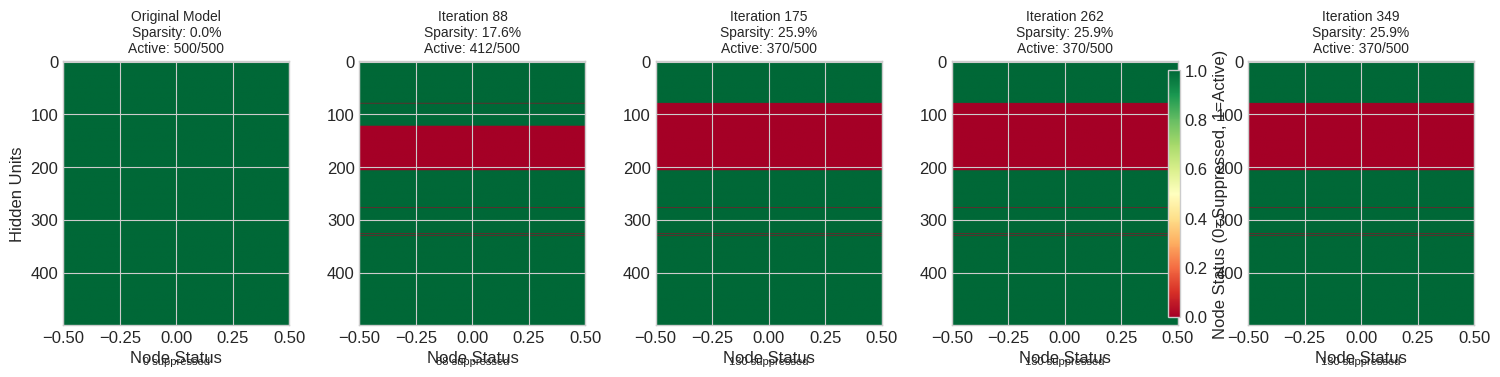

✅ Node activation patterns saved: iterative_results/node_activation_patterns.png


In [ ]:
# Visualize weight matrices at different stages of iterative suppression
if all_iterative_results:
    print("🎨 WEIGHT MATRIX VISUALIZATION")
    print("=" * 50)

    # Select models at different stages for visualization
    models_for_weight_viz = []

    # Original model
    models_for_weight_viz.append({
        'name': 'Original Model',
        'model': model,
        'iteration': 0,
        'sparsity': 0.0
    })

    # Select models at key intervals from the iterative results
    for target_name, results in all_iterative_results.items():
        if results:
            sorted_configs = sorted(results.items(),
                                    key=lambda x: x[1]['iteration'])

            # Take models at 25%, 50%, 75%, and final iteration
            total_iterations = len(sorted_configs)
            key_indices = [
                int(0.25 * total_iterations),
                int(0.5 * total_iterations),
                int(0.75 * total_iterations),
                total_iterations - 1  # Final iteration
            ]

            for idx in key_indices:
                if idx < len(sorted_configs):
                    config_name, metrics = sorted_configs[idx]
                    models_for_weight_viz.append({
                        'name':
                        f'Iteration {metrics["iteration"]}',
                        'model':
                        metrics['model'],
                        'iteration':
                        metrics['iteration'],
                        'sparsity':
                        metrics['sparsity']
                    })

    # Limit to avoid too many subplots
    models_for_weight_viz = models_for_weight_viz[:6]

    # Create weight matrix visualization
    fig, axes = plt.subplots(2,
                             len(models_for_weight_viz),
                             figsize=(4 * len(models_for_weight_viz), 8))
    if len(models_for_weight_viz) == 1:
        axes = axes.reshape(2, 1)

    for i, model_info in enumerate(models_for_weight_viz):
        current_model = model_info['model']
        model_name = model_info['name']
        iteration = model_info['iteration']
        sparsity = model_info['sparsity']

        # Get weight matrix
        W = current_model.W.detach().cpu().numpy()

        # Plot full weight matrix (top row)
        im1 = axes[0, i].imshow(W,
                                cmap='RdBu',
                                aspect='auto',
                                vmin=-0.5,
                                vmax=0.5)
        axes[0, i].set_title(f'{model_name}\nSparsity: {sparsity:.1%}',
                             fontsize=10)
        axes[0, i].set_xlabel('Visible Units')
        if i == 0:
            axes[0, i].set_ylabel('Hidden Units')

        # Calculate and show sparsity pattern (bottom row)
        # Show which hidden nodes are completely suppressed (all weights = 0)
        node_activity = np.sum(
            np.abs(W), axis=1)  # Sum of absolute weights per hidden node
        suppressed_nodes = node_activity < 1e-8

        # Create a visualization showing active vs suppressed nodes
        node_status = np.ones((model.n_hidden, 1))
        node_status[suppressed_nodes] = 0

        im2 = axes[1, i].imshow(node_status,
                                cmap='RdYlGn',
                                aspect='auto',
                                vmin=0,
                                vmax=1)
        axes[1, i].set_title(
            f'Active Nodes: {np.sum(~suppressed_nodes)}/{model.n_hidden}',
            fontsize=10)
        axes[1, i].set_xlabel('Node Status')
        if i == 0:
            axes[1, i].set_ylabel('Hidden Units')

        # Add text annotation for suppressed nodes count
        n_suppressed = np.sum(suppressed_nodes)
        axes[1, i].text(0.5,
                        -0.1,
                        f'{n_suppressed} suppressed',
                        transform=axes[1, i].transAxes,
                        ha='center',
                        fontsize=8)

    # Add colorbars
    plt.colorbar(im1, ax=axes[0, :], shrink=0.6, label='Weight Value')
    plt.colorbar(im2,
                 ax=axes[1, :],
                 shrink=0.6,
                 label='Node Status (0=Suppressed, 1=Active)')

    plt.tight_layout()
    plt.savefig('iterative_results/weight_matrix_evolution.png',
                dpi=300,
                bbox_inches='tight')
    plt.show()

    print(
        "✅ Weight matrix evolution saved: iterative_results/weight_matrix_evolution.png"
    )

else:
    print("❌ No iterative results available for weight visualization")

📊 WEIGHT DISTRIBUTION EVOLUTION


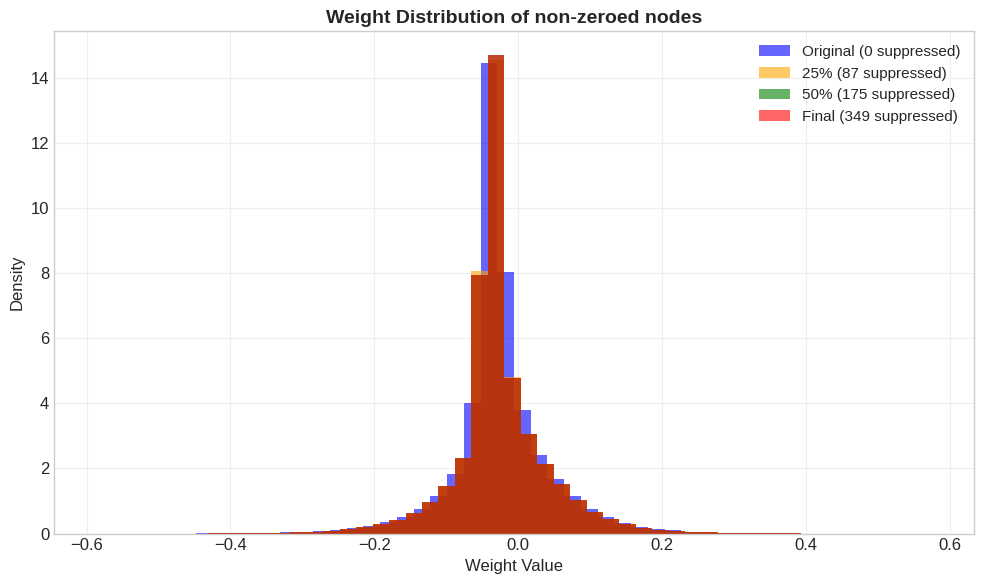

✅ Weight distribution evolution saved: iterative_results/weight_distribution_evolution.png


In [11]:
# Weight distribution evolution analysis
if all_iterative_results:
    print("📊 WEIGHT DISTRIBUTION EVOLUTION")
    print("=" * 50)

    # Create single plot for weight distribution evolution
    plt.figure(figsize=(10, 6))

    # Collect iterations for selecting key time points
    all_iterations = []
    all_models = []

    # Original model
    all_iterations.append(0)
    all_models.append(model)

    # Iterative results
    for target_name, results in all_iterative_results.items():
        if results:
            sorted_configs = sorted(results.items(),
                                    key=lambda x: x[1]['iteration'])
            for config_name, metrics in sorted_configs:
                all_iterations.append(metrics['iteration'])
                all_models.append(metrics['model'])

    # Select models at key intervals: Original, 25%, 50%, Final
    selected_indices = [
        0,
        len(all_iterations) // 4,
        len(all_iterations) // 2,
        len(all_iterations) - 1
    ]
    colors = ['blue', 'orange', 'green', 'red']
    labels = ['Original', '25%', '50%', 'Final']

    # Plot weight distribution histograms for selected iterations
    for idx, (model_idx, color,
              label) in enumerate(zip(selected_indices, colors, labels)):
        if model_idx < len(all_models):
            current_model = all_models[model_idx]
            iteration_num = all_iterations[model_idx]

            # Get weight matrix
            W = current_model.W.detach().cpu().numpy()

            # Plot histogram of non-zero weights
            non_zero_weights = W[W != 0].flatten()
            if len(non_zero_weights) > 0:
                plt.hist(non_zero_weights,
                         bins=50,
                         alpha=0.6,
                         color=color,
                         label=f'{label} ({iteration_num} suppressed)',
                         density=True)

    plt.xlabel('Weight Value', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title('Weight Distribution of non-zeroed nodes',
              fontsize=14,
              fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('iterative_results/weight_distribution_evolution.png',
                dpi=300,
                bbox_inches='tight')
    plt.show()

    print(
        "✅ Weight distribution evolution saved: iterative_results/weight_distribution_evolution.png"
    )

else:
    print("❌ No iterative results available for weight distribution analysis")

🎯 NODE SUPPRESSION PATTERN ANALYSIS


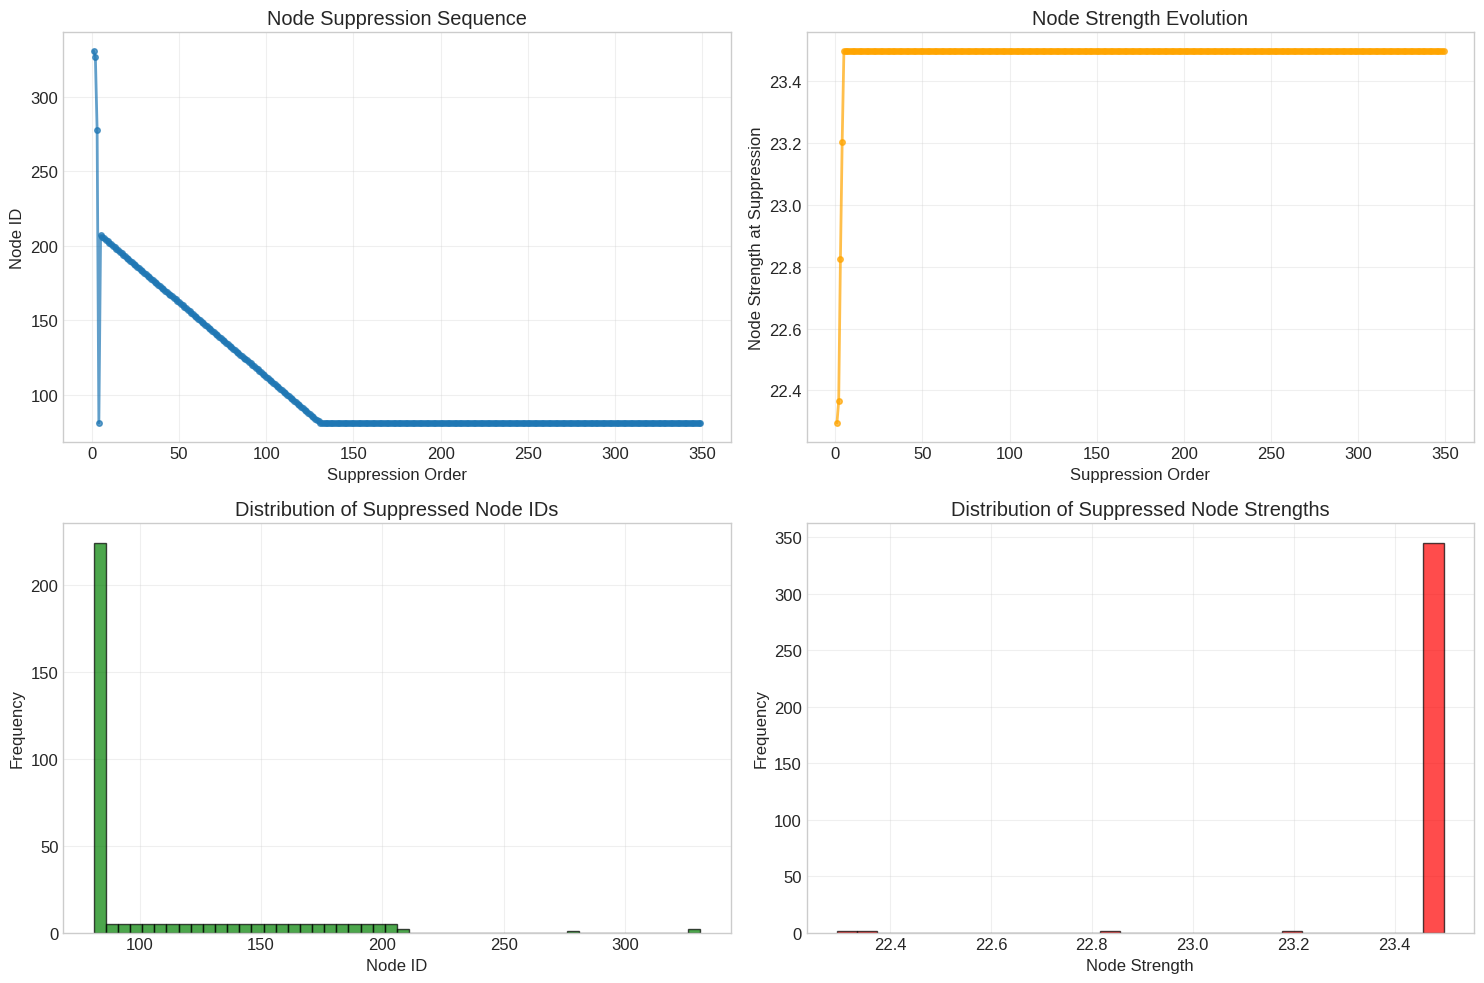

✅ Node suppression patterns saved: iterative_results/node_suppression_patterns.png

📊 SUPPRESSION PATTERN SUMMARY:
----------------------------------------
Total nodes suppressed: 349
Node ID range: 81 - 331
Average node strength at suppression: 23.4877
Node strength range: 22.2949 - 23.4972

Suppression patterns:
  First half average node ID: 131.0
  Second half average node ID: 81.0
  → No clear ID-based suppression pattern
  → Node strengths remain relatively stable (slope: 0.0002)


In [12]:
# Node suppression pattern analysis
if all_iterative_results:
    print("🎯 NODE SUPPRESSION PATTERN ANALYSIS")
    print("=" * 50)

    # Analyze which nodes were suppressed and in what order
    suppressed_nodes_sequence = []
    node_strengths_sequence = []

    for target_name, results in all_iterative_results.items():
        if results:
            sorted_configs = sorted(results.items(),
                                    key=lambda x: x[1]['iteration'])

            for config_name, metrics in sorted_configs:
                suppressed_nodes_sequence.append(metrics['suppressed_node'])
                # Convert tensor to CPU and extract scalar value
                node_strength = metrics['node_strength']
                if hasattr(node_strength, 'cpu'):
                    node_strengths_sequence.append(node_strength.cpu().item())
                else:
                    node_strengths_sequence.append(float(node_strength))

    if suppressed_nodes_sequence:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Plot 1: Suppression order (which nodes were removed when)
        axes[0, 0].plot(range(1,
                              len(suppressed_nodes_sequence) + 1),
                        suppressed_nodes_sequence,
                        'o-',
                        linewidth=2,
                        markersize=4,
                        alpha=0.7)
        axes[0, 0].set_xlabel('Suppression Order')
        axes[0, 0].set_ylabel('Node ID')
        axes[0, 0].set_title('Node Suppression Sequence')
        axes[0, 0].grid(True, alpha=0.3)

        # Plot 2: Node strength at time of suppression
        axes[0, 1].plot(range(1,
                              len(node_strengths_sequence) + 1),
                        node_strengths_sequence,
                        'o-',
                        color='orange',
                        linewidth=2,
                        markersize=4,
                        alpha=0.7)
        axes[0, 1].set_xlabel('Suppression Order')
        axes[0, 1].set_ylabel('Node Strength at Suppression')
        axes[0, 1].set_title('Node Strength Evolution')
        axes[0, 1].grid(True, alpha=0.3)

        # Plot 3: Histogram of suppressed node IDs
        axes[1, 0].hist(suppressed_nodes_sequence,
                        bins=min(50, model.n_hidden // 10),
                        alpha=0.7,
                        color='green',
                        edgecolor='black')
        axes[1, 0].set_xlabel('Node ID')
        axes[1, 0].set_ylabel('Frequency')
        axes[1, 0].set_title('Distribution of Suppressed Node IDs')
        axes[1, 0].grid(True, alpha=0.3)

        # Plot 4: Node strength distribution
        axes[1, 1].hist(node_strengths_sequence,
                        bins=30,
                        alpha=0.7,
                        color='red',
                        edgecolor='black')
        axes[1, 1].set_xlabel('Node Strength')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Distribution of Suppressed Node Strengths')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('iterative_results/node_suppression_patterns.png',
                    dpi=300,
                    bbox_inches='tight')
        plt.show()

        print(
            "✅ Node suppression patterns saved: iterative_results/node_suppression_patterns.png"
        )

        # Print analysis
        print(f"\n📊 SUPPRESSION PATTERN SUMMARY:")
        print("-" * 40)
        print(f"Total nodes suppressed: {len(suppressed_nodes_sequence)}")
        print(
            f"Node ID range: {min(suppressed_nodes_sequence)} - {max(suppressed_nodes_sequence)}"
        )
        print(
            f"Average node strength at suppression: {np.mean(node_strengths_sequence):.4f}"
        )
        print(
            f"Node strength range: {min(node_strengths_sequence):.4f} - {max(node_strengths_sequence):.4f}"
        )

        # Check if there's a pattern in suppression order
        if len(suppressed_nodes_sequence) > 10:
            # Check if lower-numbered nodes are suppressed first (or vice versa)
            first_half = suppressed_nodes_sequence[:len(
                suppressed_nodes_sequence) // 2]
            second_half = suppressed_nodes_sequence[
                len(suppressed_nodes_sequence) // 2:]

            avg_first_half = np.mean(first_half)
            avg_second_half = np.mean(second_half)

            print(f"\nSuppression patterns:")
            print(f"  First half average node ID: {avg_first_half:.1f}")
            print(f"  Second half average node ID: {avg_second_half:.1f}")

            if abs(avg_first_half - avg_second_half) > model.n_hidden * 0.1:
                if avg_first_half < avg_second_half:
                    print(
                        "  → Tendency to suppress lower-numbered nodes first")
                else:
                    print(
                        "  → Tendency to suppress higher-numbered nodes first")
            else:
                print("  → No clear ID-based suppression pattern")

        # Show strength decay pattern
        if len(node_strengths_sequence) > 5:
            strength_trend = np.polyfit(range(len(node_strengths_sequence)),
                                        node_strengths_sequence, 1)[0]
            if strength_trend < -0.001:
                print(
                    f"  → Node strengths decrease over time (slope: {strength_trend:.4f})"
                )
            elif strength_trend > 0.001:
                print(
                    f"  → Node strengths increase over time (slope: {strength_trend:.4f})"
                )
            else:
                print(
                    f"  → Node strengths remain relatively stable (slope: {strength_trend:.4f})"
                )

    else:
        print("❌ No suppression sequence data available")

else:
    print("❌ No iterative results available for suppression pattern analysis")